# Aarhus Universitet &mdash; SWMAL E25
## Assignment O4
### Gruppe 10

---

### Members

| Name                         | Student ID   |
|------------------------------|--------------|
| Per Hindbo Clausen           | 202007348    |
| Mads Kampmann Elkjær         | 202209870    |
| Daniel Them                  | 201809623    |
| Frederick Lykkegaard Nielsen | 202207768    |

---

### Hand-in Date

**04/12-2025**

# Introduction

This report presents our final end-to-end machine learning project for O4. Our goal is to build an image-classification system that predicts the breed of a cat from a photo. We will focus on five breeds, Bengal, Domestric Shorthair, Maine Coon, Ragdoll and Siamese. We want to design and implement a pipeline, so that new breeds can be added with minimal changes.

We use the Kaggle Cats Breed dataset, which gives us real world images of five different breeds with variation in resolution, lighting and background.

In the report, we follow an end-to-end structure, which defines the problem, describe the dataset, our choice of machine learning methods, explaining how we process, train, and evaluate our model. We will also discuss performance metrics, risks of under- and overfitting, and the optimizations used to improve generalization. The report concludes with key results and reflections on possible future improvements.

# Problem statement

The goal is to develop a machine learning model that can identify the breed of a cat from an image. Correctly recognizing car breeds is a task that involves understanding visual features such as fur pattern, colors, shape and orhter characteristics. However, these features could possibly be subtle and difficult to distinguish, especially on breeds that look alike.

The main challenge of real-world images, is that they can vary in lighting, resolution, pose and background, which makes it harder for a model to focus on the important features of the cat, instead of background and lighting features. Our approach includes preparing and cleaning the dataset, selecting appropriate machine learning methods, training the model and evaluation its performance using relevant metrics. We want to create a model that can somewhat reliably predict the five target cat breeds and can be expanded to include more breeds in the future.

# Dataset

### a. Concept

We want to build a robust image-classifier that predicts a cat’s breed from a single photo. The initial scope covers five breeds—Bengal, Domestic Shorthair, Maine Coon, Ragdoll, and Siamese, but the architecture will be modular (Each cat breed has their own folder) so adding new classes later requires only dropping more folders into the dataset, re-running the split and re-training or fine-tuning. We normalize inputs consistently, apply conservative augmentations to improve generalization (flip/rotate/brightness/contrast/zoom), and track performance with accuracy and macro-averaged F1. To understand model behavior, we’ll use a confusion matrix and per-class metrics; this is especially useful for visually similar breeds or when classes are imbalanced. The end product is a saved model artifact plus a small script that takes an image path and returns top-1 prediction with confidence, and maybe top-k probabilities for transparency.


### b. Dataset

We use the [Kaggle Cat's Breed Dataset](https://www.kaggle.com/datasets/yapwh1208/cats-breed-dataset), which provides exactly the five classes we target and already follows a directory-per-breed structure. This structure is compatible with standard loaders fx. (Keras `image_dataset_from_directory`) and plays nicely with reproducible train/validation/test splits. The pipeline stays open to growth: if we later collect more images for these breeds or introduce new breeds, we simply add folders with the appropriate names and rerun the preprocessing/splitting steps. This makes it straightforward to scale both the data and the classification without rewriting code.

### c. Dataset description

Each sample is a color photograph (commonly JPEG/PNG in RGB) with non-uniform resolution and aspect ratio. Labels are implicitly defined by folder names, which reduces the chance of metadata drift but can still contain occasional label noise (mis-sorted images). In a quick exploration pass, we verify the directory layout, count the images per class, and check for corrupt files or near-duplicates using a perceptual hash. We look at global summaries like width/height distributions and aspect ratios to inform the target input size and resizing policy (e.g., pad/crop vs. stretch). We also visualize single-image RGB histograms and small grids of random examples per class to spot systematic differences such as background bias (studio shots vs. household environments), lighting extremes, or watermark artifacts. To hold the scope of the project down we won't go through the pictures for background bias, as i might take a lot of time. There might be some issuese which could be mild class imbalance, resolution variance, and varied backgrounds that can mislead the model into learning context instead of the cat. 


### d. Use of dataset

We’ll use the dataset for multiclass classification: given a cat photo, predict one breed among our five classes. Classification fits because the target is a discrete label, not a numeric value (so not regression). We’ll resize and convert to RGB to standardize inputs and stabilize training, then make stratified train/validation/test splits to get fair evaluation. For metrics, we pick accuracy for overall performance and macro-F1 so small classes count equally (We might add a cat breed with not a lot of pictures). We will use a confusion matrix that shows us which breeds the model confuses.

### Sources:

- [Kaggle Cat’s Breed Dataset](https://www.kaggle.com/datasets/yapwh1208/cats-breed-dataset)
- [scikit-learn: train_test_split (stratified splitting)](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
- [scikit-learn: StratifiedKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html)
- [scikit-learn: StratifiedShuffleSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedShuffleSplit.html)
- [scikit-learn: StratifiedGroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html)
- [scikit-learn: f1_score (use `average="macro"`) ](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)
- [scikit-learn: confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
- [scikit-learn: ConfusionMatrixDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
- [scikit-learn: classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)
- [scikit-learn: cross_validate (multi-metric CV)](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html)
- [scikit-learn User Guide: Metrics & scoring (classification metrics)](https://scikit-learn.org/stable/modules/model_evaluation.html)
- [scikit-learn User Guide: Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)


We start by setting the dataset path, importing the libraries, and configuring plotting so the rest of the notebook knows where the images are and can visualize results consistently.

In [1]:
# Setup: Datapath and imports
DATA_DIR = "CatData/cat_v1"

from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.grid"] = True


Next, we scan the class folders, open each image, and record format, color mode, width, height, and aspect ratio to build a simple metadata table.

In [2]:
# Scan dataset (formats, color spaces, sizes)
IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".gif",".tif",".tiff",".webp"}

rows, bad = [], []
root = Path(DATA_DIR)
classes = sorted([d.name for d in root.iterdir() if d.is_dir()])

for cls in classes:
    for p in (root/cls).rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            try:
                with Image.open(p) as im:
                    im.load()
                    w, h = im.size
                    rows.append({
                        "path": str(p),
                        "label": cls,
                        "format": im.format,    # JPEG, PNG, ...
                        "mode": im.mode,        # RGB, L, RGBA, ...
                        "width": w,
                        "height": h,
                        "aspect": (w/h if h else np.nan)
                    })
            except (UnidentifiedImageError, OSError):
                bad.append(str(p))

meta = pd.DataFrame(rows)
print(f"Classes: {classes}")
print(f"Total images: {len(meta)}  |  Unreadable: {len(bad)}")
meta.head()


Classes: ['bengal', 'domestic_shorthair', 'maine_coon', 'ragdoll', 'siamese']
Total images: 952  |  Unreadable: 0


,path,label,format,mode,width,height,aspect
0,CatData\cat_v1\bengal\00438-Bengal-cat-snarlin...,bengal,JPEG,RGB,1120,1104,1.014493
1,CatData\cat_v1\bengal\00441-Very-timid-Brown-S...,bengal,JPEG,RGB,1414,1104,1.280797
2,CatData\cat_v1\bengal\00e79f939696ea0c09560315...,bengal,JPEG,RGB,2554,3222,0.792675
3,CatData\cat_v1\bengal\03915-Pair-of-Bengal-kit...,bengal,JPEG,RGB,1102,1104,0.998188
4,CatData\cat_v1\bengal\04413-Bengal-cat-white-b...,bengal,JPEG,RGB,1038,1104,0.940217


Then we print a directory tree to document how the data are organized on disk, showing the root and the class subfolders.

In [3]:
# Representation on disk (folder structure)
def print_tree(path: Path, max_depth=1):
    def _walk(p, prefix="", depth=0):
        if depth > max_depth: return
        entries = sorted(p.iterdir(), key=lambda x: (not x.is_dir(), x.name.lower()))
        for i, e in enumerate(entries[:50]):  # truncate for readability
            is_last = (i == len(entries)-1)
            branch = "└── " if is_last else "├── "
            print(prefix + branch + e.name + ("/" if e.is_dir() else ""))
            if e.is_dir():
                _walk(e, prefix + ("    " if is_last else "│   "), depth+1)
    print(p.name + "/")
    _walk(path)

print_tree(root, max_depth=1)


zxtw5kluwri21.jpg/
├── bengal/
│   ├── 00438-Bengal-cat-snarling.jpg
│   ├── 00441-Very-timid-Brown-Spotted-Bengal-cat-ears-back.jpg
│   ├── 00e79f939696ea0c095603154c4af840.jpg
│   ├── 03915-Pair-of-Bengal-kittens-white-background.jpg
│   ├── 04413-Bengal-cat-white-background.jpg
│   ├── 047ffa2f7165ccc4585e418ddb800299.jpg
│   ├── 05050-Brown-spotted-Bengal-cat-sitting-on-grey-background.jpg
│   ├── 09a0c5d574f818471c84cf509fc786dc.jpg
│   ├── 0c87060cea587a01f0a254066c95deaa.jpg
│   ├── 106f59608bc9fc6ac11df31008efdf94.jpg
│   ├── 1096165.jpg
│   ├── 1111246.jpg
│   ├── 1113154.jpg
│   ├── 1142194.jpg
│   ├── 119mokiL1.jpg
│   ├── 1200px-Bangie_the_Bengal_Cat.jpg
│   ├── 122433177_3649288731759742_6202950879910256561_o.jpg
│   ├── 12651963_f520.jpg
│   ├── 14105889_f520.jpg
│   ├── 15658-Brown-spotted-Bengal-female-cat.jpg
│   ├── 15a0a84bd11fcae601ed41f5672191ba.jpg
│   ├── 1aeae43be56c47450ef4a3354d3e940d.jpg
│   ├── 1b2a68f85a32410fb3fd776927a2f4ef.jpg
│   ├── 1e8351aa322b32f7a23

After that, we show class counts and simple tables of image formats and color modes. This checks how balanced the classes are and what kinds of files we have.

In [4]:
# Basic tables
# Class counts
cls_counts = meta["label"].value_counts().sort_index()
display(pd.DataFrame({"count": cls_counts}))

# Formats & color spaces
display(meta["format"].value_counts().to_frame("count").rename_axis("format"))
display(meta["mode"].value_counts().to_frame("count").rename_axis("mode"))


,count
label,
bengal,177
domestic_shorthair,170
maine_coon,190
ragdoll,207
siamese,208


,count
format,
JPEG,942
PNG,7
MPO,2
WEBP,1


,count
mode,
RGB,947
RGBA,2
P,2
L,1


We then compute size stats per class and plot histograms of width, height, and aspect ratio. This tells us how big images are and helps if we want to choose a standard resize.

width                                  height               \
                   count   min  median         mean   max  count  min  median   
label                                                                           
bengal               177  1024  1500.0  1913.604520  6016    177  768  1200.0   
domestic_shorthair   170  1024  1630.0  2084.317647  7793    170  768  1600.0   
maine_coon           190  1024  1393.0  1710.752632  5616    190  768  1350.0   
ragdoll              207  1024  1530.0  1855.347826  6000    207  768  1448.0   
siamese              208  1024  1536.0  2027.235577  6000    208  768  1488.5   

                                      aspect                                \
                           mean   max  count       min    median      mean   
label                                                                        
bengal              1598.355932  4928    177  0.577622  1.333333  1.250921   
domestic_shorthair  1971.905882  5472    170  0.486477  1.157033  1.124896   
maine_coon          1678.478947  6000    190  0.598822  1.000000  1.096011   
ragdoll             1722.719807  5389    207  0.607389  1.250000  1.155491   
siamese             1799.307692  4630    208  0.495495  1.332845  1.191017   

                             megapix                                         
                         max   count       min  median      mean        max  
label                                                                        
bengal              1.870130     177  0.786432  1.7370  3.835617  24.064000  
domestic_shorthair  1.784917     170  0.786432  2.6650  4.950322  40.484635  
maine_coon          1.901205     190  0.786432  1.9200  3.506636  25.000000  
ragdoll             1.959565     207  0.786432  2.0736  3.815713  24.000000  
siamese             2.370370     208  0.786432  2.2500  4.451752  24.000000

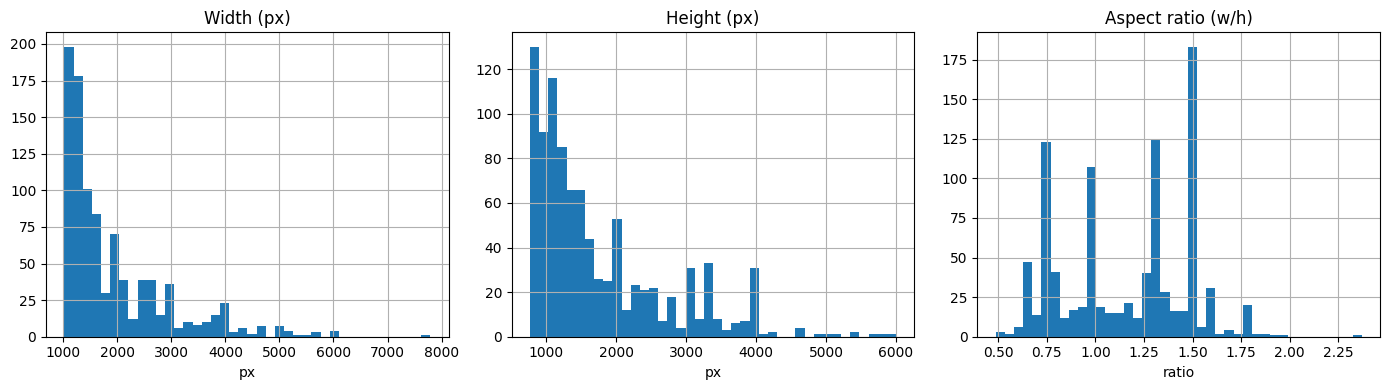

In [5]:
# Size statistics + histograms (width/height/aspect)
size_stats = (meta
    .assign(megapix=(meta["width"]*meta["height"])/1e6)
    .groupby("label")[["width","height","aspect","megapix"]]
    .agg(["count","min","median","mean","max"]))
display(size_stats)

fig, axes = plt.subplots(1,3, figsize=(14,4))
axes[0].hist(meta["width"],  bins=40); axes[0].set_title("Width (px)");  axes[0].set_xlabel("px")
axes[1].hist(meta["height"], bins=40); axes[1].set_title("Height (px)"); axes[1].set_xlabel("px")
axes[2].hist(meta["aspect"], bins=40); axes[2].set_title("Aspect ratio (w/h)"); axes[2].set_xlabel("ratio")
plt.tight_layout(); plt.show()


Next, we show a small grid of example images for each class with their labels. This is a quick visual check that the data look right.

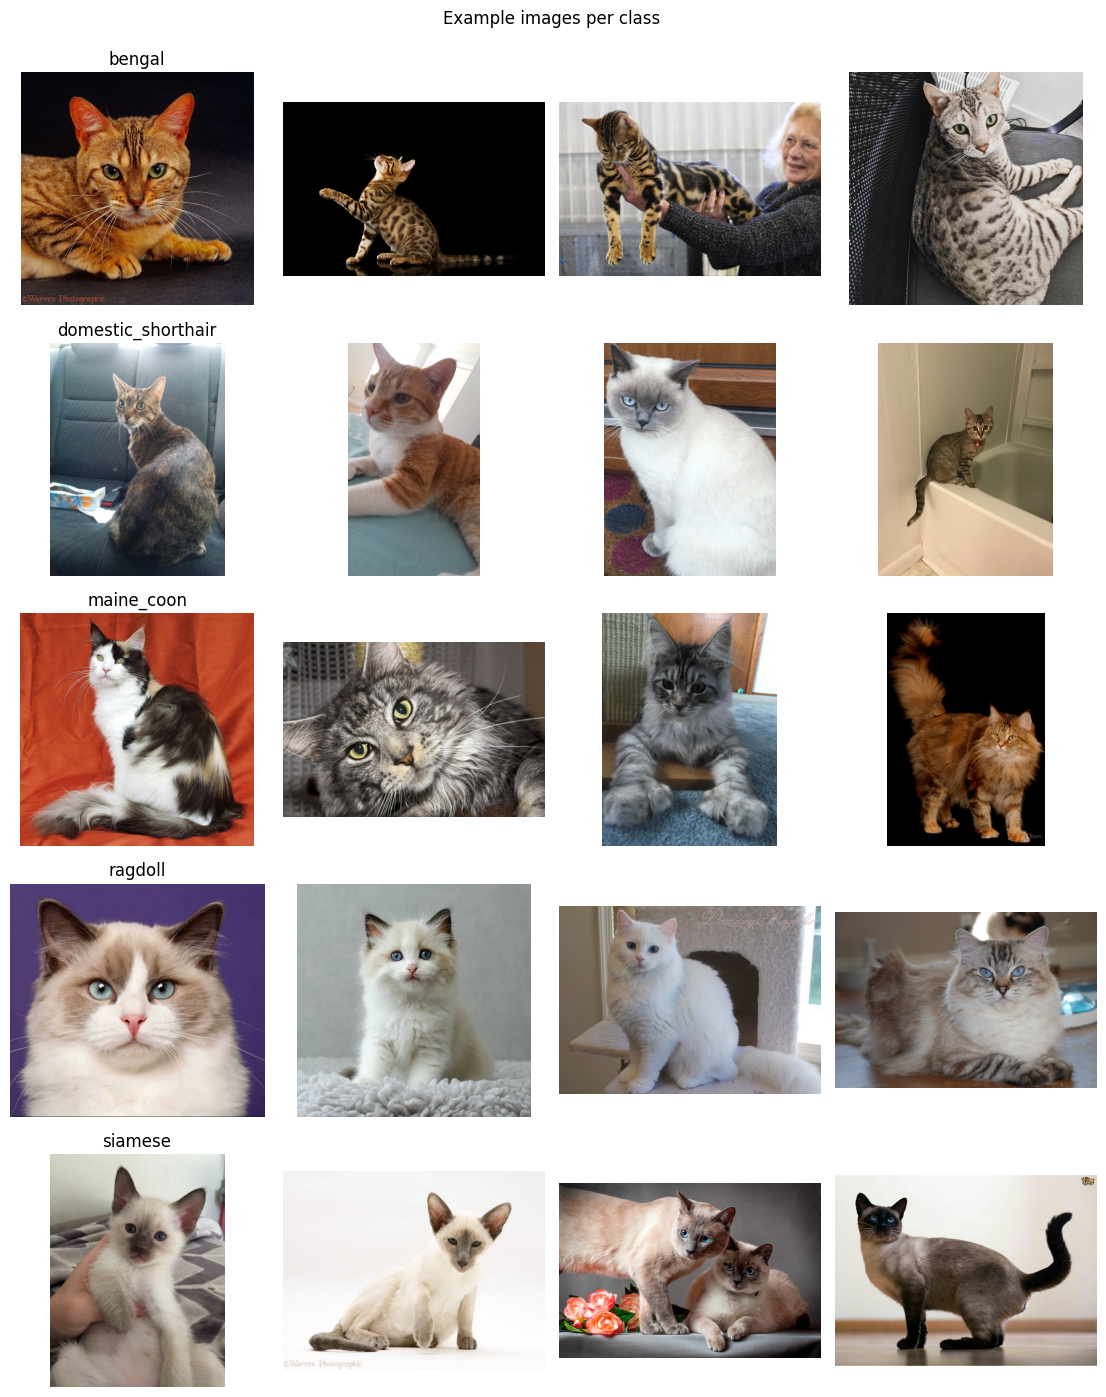

In [6]:
# Examples & labels (image grid)
def show_examples(df, per_class=4):
    labels = sorted(df["label"].unique())
    nrows, ncols = len(labels), per_class
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.8*ncols, 2.8*nrows))
    if nrows == 1: axes = np.array([axes])
    for r, lab in enumerate(labels):
        subset = df[df["label"]==lab]
        sample = subset.sample(min(per_class, len(subset)), random_state=42)
        for c, (_, row) in enumerate(sample.iterrows()):
            ax = axes[r, c] if ncols>1 else axes[r, 0]
            img = Image.open(row["path"]).convert("RGB")
            ax.imshow(img); ax.set_axis_off()
            if c == 0: ax.set_title(lab)
    plt.suptitle("Example images per class", y=0.995)
    plt.tight_layout(); plt.show()

show_examples(meta, per_class=4)


We also plot RGB histograms for one image per class. That gives a basic view of brightness and color for single images.

Single-image histograms (one per class):


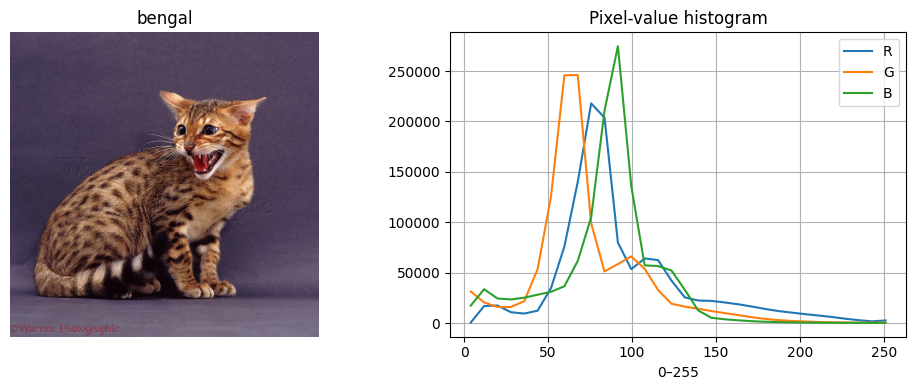

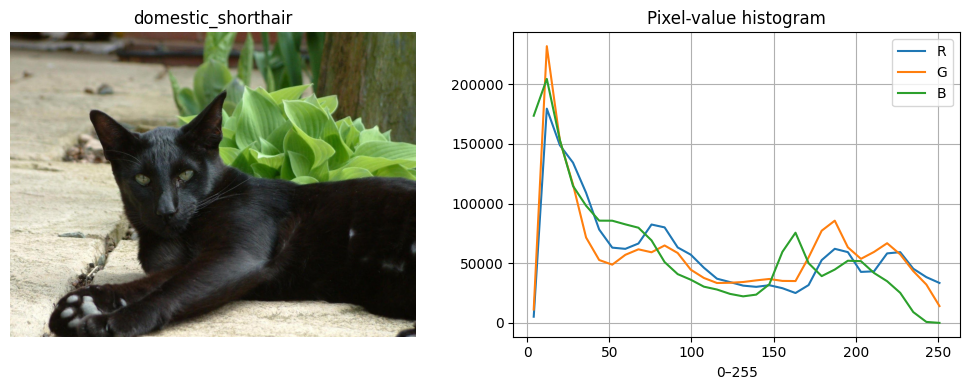

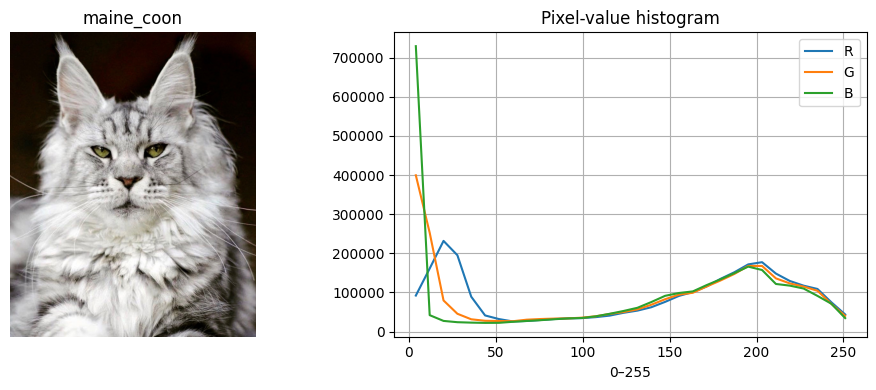

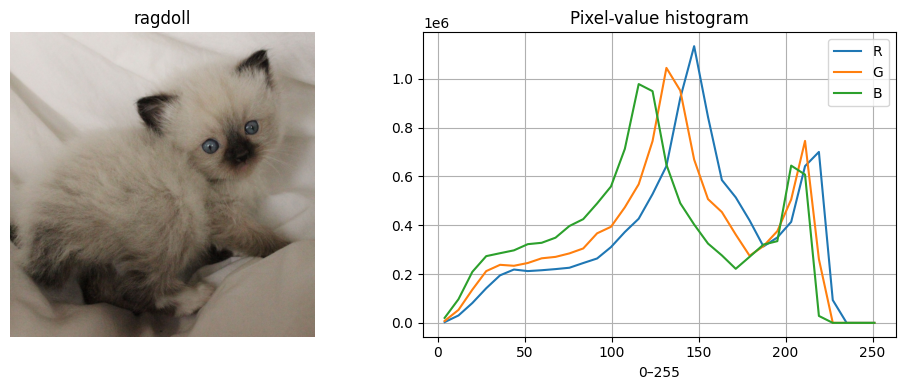

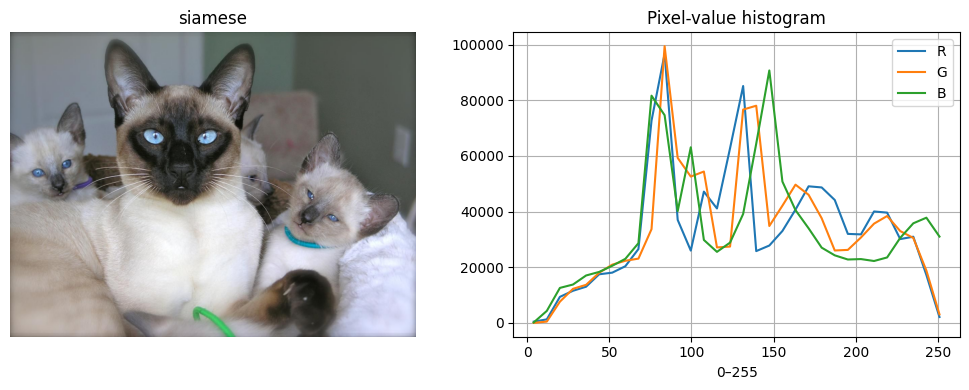

In [7]:
# Histograms on individual images
def plot_image_and_histogram(image_path, bins=32):
    im = Image.open(image_path).convert("RGB")
    arr = np.asarray(im, dtype=np.uint8)
    fig = plt.figure(figsize=(10,4))
    ax1 = plt.subplot(1,2,1)
    ax1.imshow(im); ax1.set_axis_off(); ax1.set_title(Path(image_path).parent.name)
    ax2 = plt.subplot(1,2,2)
    for ch, name in enumerate(["R","G","B"]):
        hist, edges = np.histogram(arr[...,ch].ravel(), bins=bins, range=(0,255))
        centers = 0.5*(edges[1:]+edges[:-1])
        ax2.plot(centers, hist, label=name)
    ax2.set_title("Pixel-value histogram"); ax2.set_xlabel("0–255"); ax2.legend()
    plt.tight_layout(); plt.show()

print("Single-image histograms (one per class):")
for lab in sorted(meta["label"].unique()):
    ex = meta[meta["label"]==lab]
    if len(ex):
        plot_image_and_histogram(ex.iloc[0]["path"], bins=32)


The above data analysis gives us a clear picture of what the dataset includes. We know the folder layout for loaders, the class balance, typical image sizes and aspect ratios, and the formats/color modes. Hopefully this will help us be more prepared for the later challenge of actually training a model.

In [8]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import shutil

def standardize_images(
    df, 
    out_root="CatData/_tmp_standardized",
    target_size=(224,224),
    out_format="JPEG",
    quality=95,
    preserve_structure=True,
    letterbox=False,
    bg_color=(0,0,0),
    val_fraction=0.10,               # <-- NEW (10% validation)
    random_state=42
):
    """
    df: metadata dataframe with columns 'path','label'
    out_root: output base directory
    val_fraction: fraction of samples sent to validation set
    """

    # Clean output directory
    out_root = Path(out_root)
    if out_root.exists():
        shutil.rmtree(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    rng = np.random.default_rng(random_state)

    # Decide train/val assignment
    mask = rng.random(len(df)) < val_fraction
    df = df.copy()
    df["split"] = np.where(mask, "val", "train")

    counts = 0
    for _, row in df.iterrows():
        src = Path(row["path"])
        label = row["label"]
        split = row["split"]

        try:
            with Image.open(src) as im:
                im = im.convert("RGB")

                if letterbox:
                    im.thumbnail(target_size, Image.Resampling.LANCZOS)
                    canvas = Image.new("RGB", target_size, bg_color)
                    off_x = (target_size[0] - im.width) // 2
                    off_y = (target_size[1] - im.height) // 2
                    canvas.paste(im, (off_x, off_y))
                    out_im = canvas
                else:
                    out_im = ImageOps.fit(im, target_size, Image.Resampling.LANCZOS)

                # Build output folder: train/label or val/label
                split_dir = out_root / split
                subdir = split_dir / label if preserve_structure else split_dir
                subdir.mkdir(parents=True, exist_ok=True)

                out_name = src.stem + "." + ("jpg" if out_format.upper()=="JPEG" else out_format.lower())
                out_path = subdir / out_name

                save_kwargs = {}
                if out_format.upper() == "JPEG":
                    save_kwargs.update({"quality": quality, "optimize": True})

                out_im.save(out_path, out_format, **save_kwargs)
                counts += 1

        except Exception as e:
            print(f"Failed {src}: {e}")

    print(f"Standardized {counts} images -> {out_root}")
    print(f"Train size: {(df['split']=='train').sum()}")
    print(f"Val size: {(df['split']=='val').sum()}")

#   Run it
standardize_images(meta, target_size=(224,224), out_format="JPEG", letterbox=False)


Standardized 952 images -> CatData\_tmp_standardized
Train size: 860
Val size: 92


# Choice of ML algorithm

For this project we frame cat-breed recognition as a supervised multiclass image-classification problem as each input image is paired with a known breed label, and the model must assign one of five possible classes (Bengal, Domestic Shorthair, Maine Coon, Ragdoll, Siamese). Because the input data are images with a clear two-dimensional spatial structure, we use computer-vision methods rather than generic tabular algorithms. Convolutional neural networks (CNNs) are the standard choice for image recognition on large datasets such as ImageNet.

CNNs are well suited to this task because they exploit the topology of image data through local receptive fields and weight sharing. This allows the network to learn translation-invariant features, so if the cat is shifted, rotated, or appears at a different scale, the same convolutional filters can still detect relevant visual patterns such as edges, fur textures, and facial structures. Instead of relying on hand-crafted features like manually defined color histograms or shape descriptors, the CNN automatically learns a hierarchy of representations, from low-level edges and corners in the early layers to higher-level concepts such as ears, eyes, and overall head shape in deeper layers. This makes CNNs more robust to variations in pose, lighting, and background that characterize real-world cat photos.

Training a deep CNN from scratch usually requires very large labeled datasets and substantial computational resources. Our cat-breed dataset is much smaller (952) than ImageNet (14 million), so directly learning all weights from random initialization would increase the risk of overfitting and lengthen training time. To address this, we adopt transfer learning, which is standard practice for image classification when data are limited. We reuse a pre-trained CNN, Inception v3, which is originally trained on more than one million images and 1,000 object categories from the ImageNet dataset. Inception v3 is a deep, optimized CNN architecture that combines convolutional, pooling, and “Inception” modules to achieve strong accuracy without using too much computational powers.

In our transfer-learning setup, the lower and middle layers of the pre-trained Inception v3 model are frozen, because they capture generic visual features such as edges, textures, and simple shapes that are useful for almost any image domain. Only the final classification layers are replaced and retrained on our five cat-breed classes. This approach drastically reduces training time and data requirements while typically improving generalization compared with training a similar-sized network from scratch on a small dataset.

We implement our model in Python using TensorFlow and its high-level Keras API. Keras provides a simple way to define, train, and evaluate deep learning models, while TensorFlow handles the underlying computation efficiently on both CPU and GPU. This framework also offers built-in support for loading pre-trained models such as Inception v3 and makes it straightforward to fine-tune them for our specific cat-breed classification task.


## Sources 

- [Szegedy, C. et al. “Rethinking the Inception Architecture for Computer Vision.” CVPR, 2016.](https://arxiv.org/abs/1512.00567)  
- [ImageNet Project. “About ImageNet.”](https://www.image-net.org/about.php)  
- [Kaggle. “Inception V3 Model”](https://www.kaggle.com/datasets/generalerror/torchvision-inception-v3-imagenet-pretrained)  
- [Tensorflow Learn. “Convolutional Neural Network (CNN)”](https://www.tensorflow.org/tutorials/images/cnn)  
- [Wikipedia. “Convolutional Neural Network.”](https://en.wikipedia.org/wiki/Convolutional_neural_network)  
- [Wikipedia. “Inception (deep learning architecture).”](https://en.wikipedia.org/wiki/Inceptionv3)  
- [Keras: Transfer learning & fine-tuning”](https://keras.io/guides/transfer_learning/)

# ML Data processing
her

# Performance metrics
Here

# Under- and overfitting
here

# Conclusion
Here

# KODE

In [9]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models

NUM_CAT_BREEDS = 5
width, height = 299, 299

base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(width,height,3)
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [10]:
base_model.trainable = False

In [11]:
inputs = tf.keras.Input(shape=(width, height, 3))

In [12]:
from tensorflow.keras.applications.inception_v3 import preprocess_input

In [13]:
x = preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CAT_BREEDS, activation="softmax")(x)

model = models.Model(inputs, outputs)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [15]:
IMG_SIZE = (width, height)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "CatData/_tmp_standardized/train",
    validation_split=.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "CatData/_tmp_standardized/val",
    validation_split=.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(class_names)

Found 859 files belonging to 5 classes.
Using 688 files for training.
Found 92 files belonging to 5 classes.
Using 74 files for training.
['bengal', 'domestic_shorthair', 'maine_coon', 'ragdoll', 'siamese']


In [16]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(.1),
    tf.keras.layers.RandomZoom(.1)
])

In [17]:
# Include augmentation in the model
x = data_augmentation(inputs)
x = base_model(x, training=False)

In [18]:
# Train the head
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.5523 - loss: 1.1590 - val_accuracy: 0.6757 - val_loss: 0.7767
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.7631 - loss: 0.6634 - val_accuracy: 0.8108 - val_loss: 0.5314
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.8154 - loss: 0.5501 - val_accuracy: 0.8378 - val_loss: 0.4031
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.8270 - loss: 0.4764 - val_accuracy: 0.8649 - val_loss: 0.4127
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.8532 - loss: 0.4031 - val_accuracy: 0.8649 - val_loss: 0.3806
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.8765 - loss: 0.3675 - val_accuracy: 0.8784 - val_loss: 0.3988
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.8547 - loss: 0.4015 - val_accuracy: 0.8784 - val_loss: 0.4151
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.8735 - loss: 0.3404 - val_accuracy: 0.8649 - val_loss:

In [19]:
# Fine tuning the top of InceptionV3
base_model.trainable = True

fine_tune_from = 249

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.7660 - loss: 0.5908 - val_accuracy: 0.8514 - val_loss: 0.3979
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.8953 - loss: 0.3250 - val_accuracy: 0.8649 - val_loss: 0.3930
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9302 - loss: 0.2321 - val_accuracy: 0.8784 - val_loss: 0.3848
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9491 - loss: 0.1906 - val_accuracy: 0.9054 - val_loss: 0.3873
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9666 - loss: 0.1475 - val_accuracy: 0.9054 - val_loss: 0.3845


# MANUAL TEST

In [20]:
def TestImage(imgpath):
    img = tf.keras.utils.load_img(imgpath, target_size=IMG_SIZE)

    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)[0]

    for name, p in sorted(zip(class_names, predictions), key=lambda x: -x[1]):
        print(f"{name:20s} {p:.3f}")


In [28]:
TestImage("CatData/cat_v1/ragdoll/Ragdoll-2.jpg")

TestImage("CatData/cat_v1/maine_coon/5a40909340d5251a5d24df5fca8ff16d.jpg")

TestImage("CatData/cat_v1/domestic_shorthair/04f2e5e2f67443c7c3299ce4078dc2a2.jpg")
# TestImage("CatData/cat_v1/bengal/1aeae43be56c47450ef4a3354d3e940d.jpg")

TestImage("CatData/cat_v1/bengal/3eb7e9a7542bdead2c633e4a2b06a588.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
ragdoll              0.783
siamese              0.214
domestic_shorthair   0.002
maine_coon           0.000
bengal               0.000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
maine_coon           0.990
ragdoll              0.005
domestic_shorthair   0.005
siamese              0.000
bengal               0.000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
domestic_shorthair   0.960
bengal               0.028
maine_coon           0.008
siamese              0.004
ragdoll              0.000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
domestic_shorthair   0.507
bengal               0.488
siamese              0.004
maine_coon           0.000
ragdoll              0.000


# Optimizations and improvements
### Confusion matrix


y_true shape: (74,)
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 456ms/step
y_pred_raw shape: (74, 5)
y_pred shape: (74,)


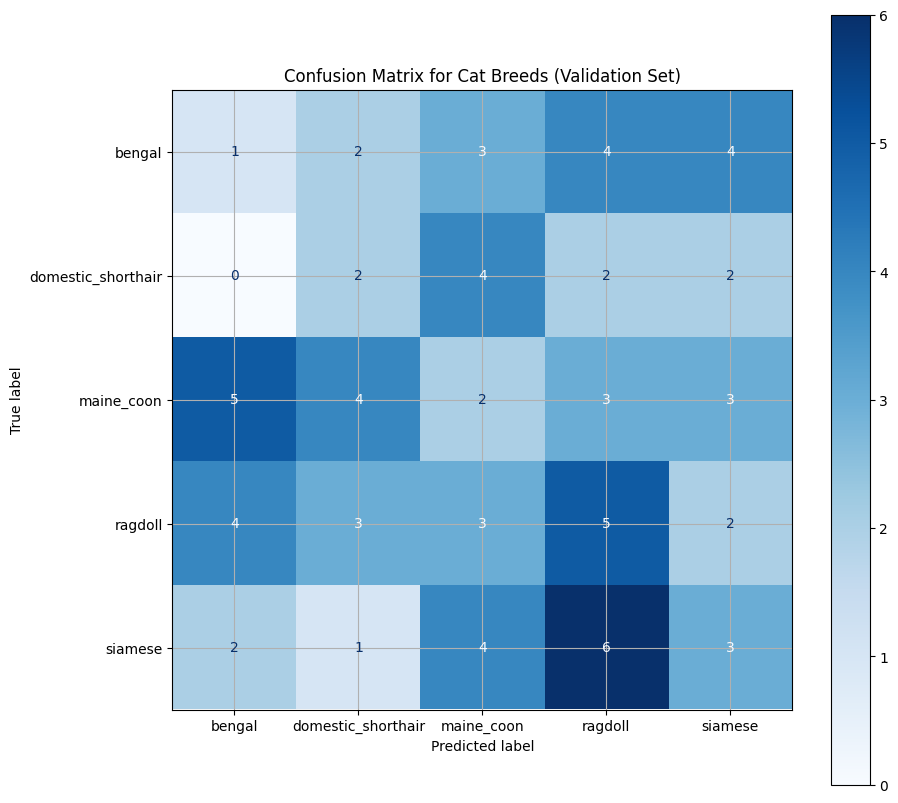

In [40]:

import sklearn

# 1. Hent Sande Etiketter (True Labels)
# Samler alle 'y' værdier (labels) fra valideringssættet.
y_true = []
for images, labels in val_ds:
    # labels.numpy() konverterer tf.Tensor til NumPy array
    y_true.extend(labels.numpy())
    
y_true = np.array(y_true)
print(f"y_true shape: {y_true.shape}")

# 2. Hent Modellens Rå Forudsigelser (Probabilities)
# model.predict tager hele val_ds datasættet som input
y_pred_raw = model.predict(val_ds)
print(f"y_pred_raw shape: {y_pred_raw.shape}")
# Bør være (antal billeder, 5 racer)

# 3. Konverter Sandsynligheder til Klasser
# np.argmax vælger indexet (klassenummeret) med den højeste sandsynlighed
y_pred = np.argmax(y_pred_raw, axis=1)
print(f"y_pred shape: {y_pred.shape}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Kør de ovenstående trin 1 og 2 for at få y_true og y_pred...

# 4. Generer Matricen
cm = confusion_matrix(y_true, y_pred)

# 5. Visualiser Matricen
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=class_names # class_names fik du fra val_ds
)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Cat Breeds (Validation Set)")
plt.show()

